In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np

In [2]:
df = pd.read_csv('amz_uk_price_prediction_dataset.csv')

### Part 1: Understanding Product Categories

**Business Question**: What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?

1. **Frequency Tables**:
    - Generate a frequency table for the product `category`.
    - Which are the top 5 most listed product categories?

In [3]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [4]:
df.shape

(2443651, 9)

In [5]:
category_frequency = df['category'].value_counts().to_frame('count').head()
category_frequency


,count
category,
Sports & Outdoors,836265
Beauty,19312
"Handmade Clothing, Shoes & Accessories",19229
Bath & Body,19092
Birthday Gifts,18978


In [6]:
my_table = pd.crosstab(index=df['category'], columns=['count']).rename_axis(columns=None).sort_values(by='count', ascending=False).head()
my_table

,count
category,
Sports & Outdoors,836265
Beauty,19312
"Handmade Clothing, Shoes & Accessories",19229
Bath & Body,19092
Birthday Gifts,18978


2. **Visualizations**:
    - Display the distribution of products across different categories using a bar chart. *If you face problems understanding the chart, do it for a subset of top categories.*
    - For a subset of top categories, visualize their proportions using a pie chart. Does any category dominate the listings?

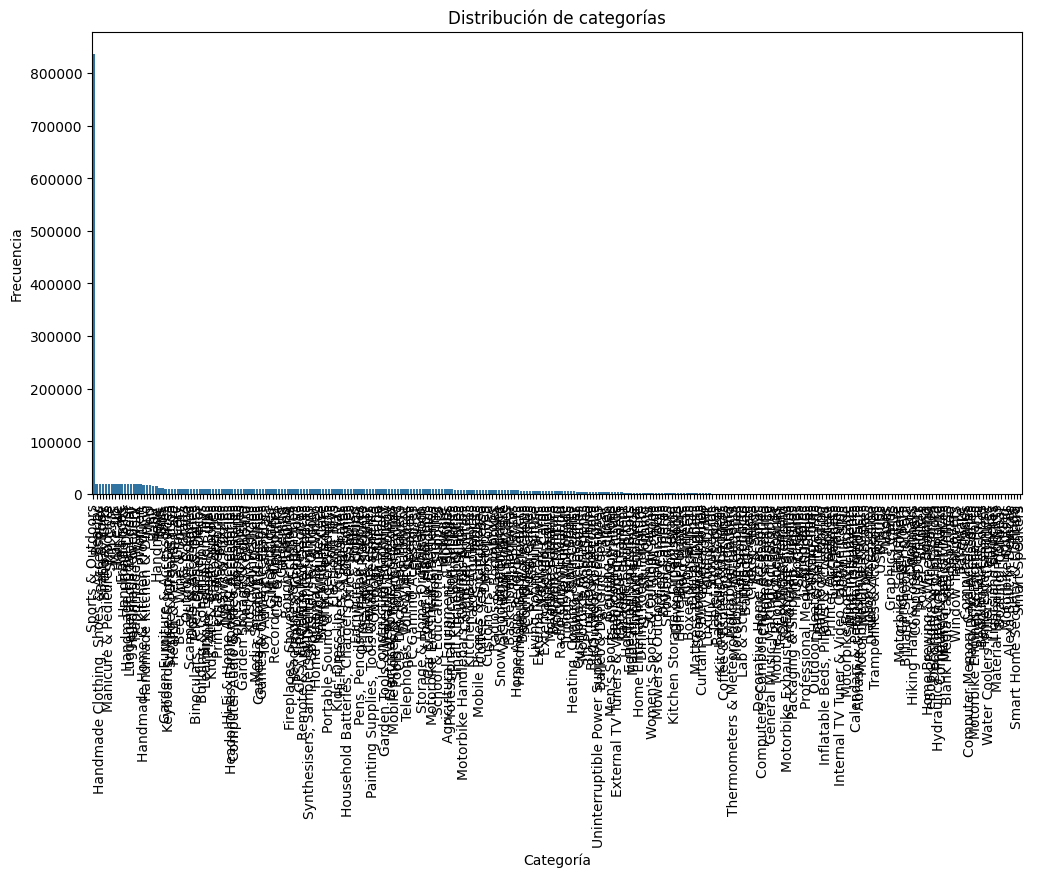

In [7]:
plt.figure(figsize=(12, 6))
barplot_cat = sns.barplot(x=  df['category'].value_counts().index, y=  df['category'].value_counts().values)
plt.title('Distribución de categorías')
plt.xlabel('Categoría')
plt.ylabel('Frecuencia')
plt.xticks(rotation=90)
plt.show()

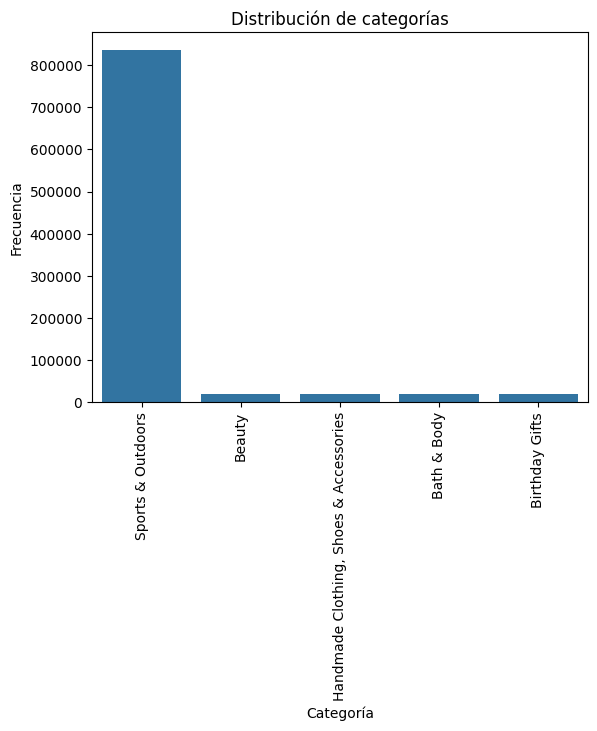

In [23]:
barplot_cat = sns.barplot(x= my_table.index, y= my_table['count'].values)
plt.title('Distribución de categorías')
plt.xlabel('Categoría')
plt.ylabel('Frecuencia')
plt.xticks(rotation=90)
plt.show()

Text(0, 0.5, 'Frecuencia')

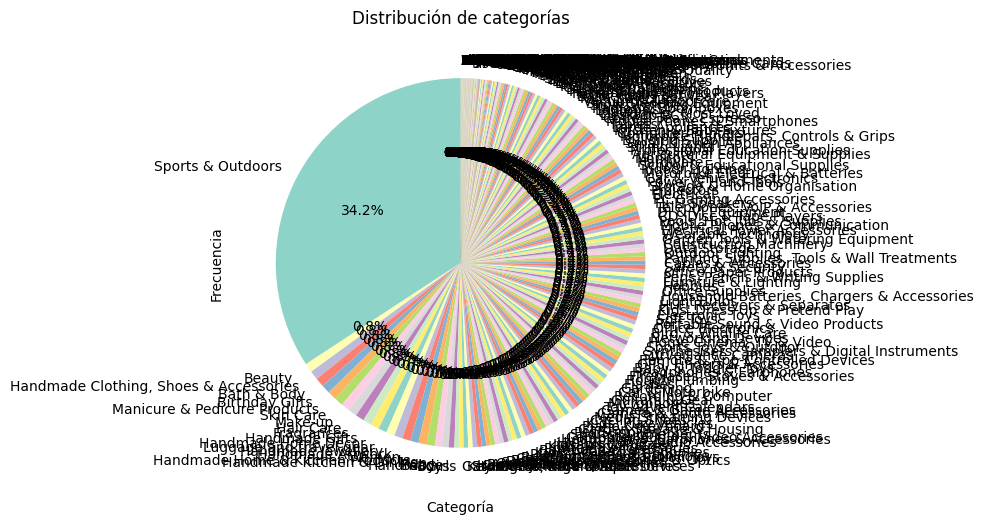

In [9]:
plt.figure(figsize=(12, 6))
df['category'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=sns.color_palette("Set3"))
plt.title('Distribución de categorías')
plt.xlabel('Categoría')
plt.ylabel('Frecuencia')


### Part 2: Delving into Product Pricing

**Business Question**: How are products priced on Amazon UK, and are there specific price points or ranges that are more common?

1. **Measures of Centrality**:
    - Calculate the mean, median, and mode for the `price` of products.
    - What's the average price point of products listed? How does this compare with the most common price point (mode)?


In [10]:
mean = df['price'].mean()
median = df['price'].median()
mode = df['price'].mode()[0]
mean, median, mode

(np.float64(89.24380943923661), np.float64(19.09), np.float64(9.99))

media = 89
moda = 10
hay presencia de valores extremos que empujan los precios hacia arriba como se observa en la diferencia de valor entre media (89) y moda (10)

2. **Measures of Dispersion**:
    - Determine the variance, standard deviation, range, and interquartile range for product `price`.
    - How varied are the product prices? Are there any indicators of a significant spread in prices?

In [24]:
var = df['price'].var()
std = df['price'].std()
range = df['price'].max() - df['price'].min()
q25 = df['price'].quantile(0.25)
q75 = df['price'].quantile(0.75)
IQR = q75 - q25
var, std, range, q25, q75, IQR

(np.float64(119445.48532254901),
 np.float64(345.60886175349873),
 np.float64(100000.0),
 np.float64(9.99),
 np.float64(45.99),
 np.float64(36.0))

una STD tan alta indica gran dispersion de los datos. El hecho de tener un rango de 100000 por si solo no indica mucho salvo que los precios son muy variados pudiendo ser tan solo dos precios que van desde 1 euro hasta 100001 euros pero observando los quartiles q1 y q2 el 75% de los precios se encuentran entre los 0 y 46 euros y el 25% restante (q3) acapara precios desde los 46 hasta el valor maximo que son 100000. muy pocos productos tienen precios muy elevados.

3. **Visualizations**:
    - Is there a specific price range where most products fall? Plot a histogram to visualize the distribution of product prices. *If its hard to read these diagrams, think why this is, and explain how it could be solved.*.
    - Are there products that are priced significantly higher than the rest? Use a box plot to showcase the spread and potential outliers in product pricing. 

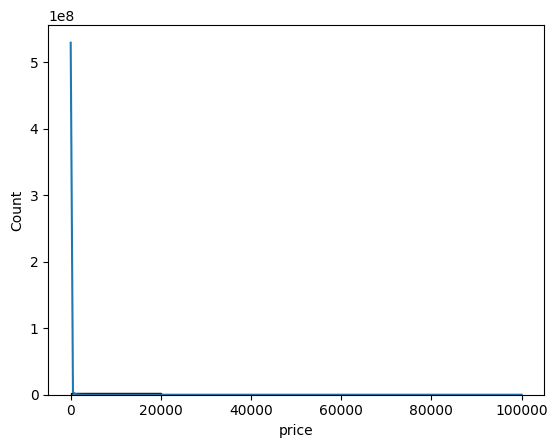

In [12]:
hist_price = sns.histplot(data= df, x= df['price'], bins=5, kde=True)

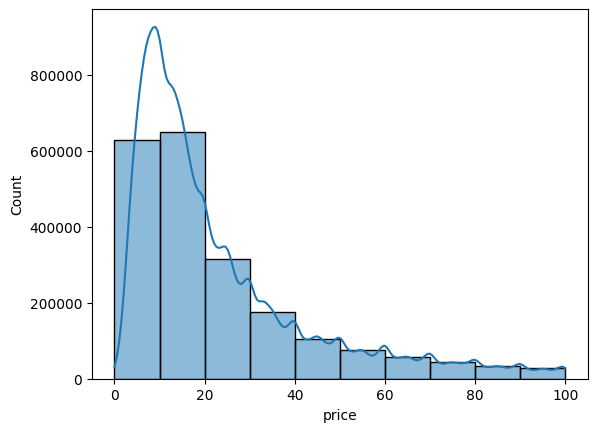

In [13]:
'''
El problema de la variable price es que tiene un rango muy amplio con gran cantidad de records (75%) entre 0 y 46, lo que hace que la mayoría de los datos se agrupen en el extremo izquierdo del histograma. 
Para solucionar esto, podemos aplicar una transformación a la variable price antes de graficarla eliminando los valores extremos altos. Esto ayudará a reducir la escala y a distribuir mejor los datos en el histograma.
'''
df_filtered = df[df['price'] < (df['price'].quantile(0.75) + 1.5 * (df['price'].quantile(0.75) - df['price'].quantile(0.25)))] 
hist_price_filtered = sns.histplot(data= df_filtered, x= df_filtered['price'], bins=10, kde=True)

El mayor numero precios caen dentro de los valores entre 0 y 20 

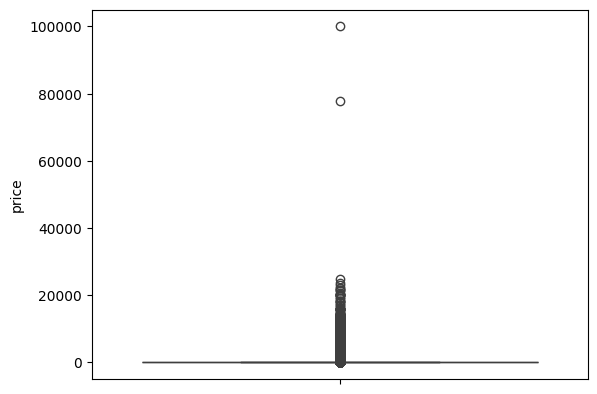

In [14]:
boxplot_price = sns.boxplot(data= df['price'])

Se observan varios valores atípicos en la variable price, lo que indica que hay registros con precios extremadamente altos en comparación con el resto de los datos. 
Estos valores atípicos pueden influir en las medidas de tendencia central y dispersión, por lo que es importante considerarlos al analizar la variable price.

### Part 3: Unpacking Product Ratings

**Business Question**: How do customers rate products on Amazon UK, and are there any patterns or tendencies in the ratings?

1. **Measures of Centrality**:
    - Calculate the mean, median, and mode for the `rating` of products.
    - How do customers generally rate products? Is there a common trend?

In [15]:
rating_mean = df[df['stars'] > 0]['stars'].mean()
rating_median = df[df['stars'] > 0]['stars'].median()
rating_mode = df[df['stars'] > 0]['stars'].mode()[0]
rating_mean, rating_median, rating_mode

(np.float64(4.319160762226911), np.float64(4.4), np.float64(4.5))

si eliminamos los valores correspondiente a 0 en la variable stars (se asume que valores de 0 indican que no se ha votado) la tendencia general a la hora de calificar un producto es hacia el alza con valores de media, mediana y moda practicamente similares. presentando un distribucion normal

2. **Measures of Dispersion**:
    - Determine the variance, standard deviation, and interquartile range for product `rating`.
    - Are the ratings consistent, or is there a wide variation in customer feedback?

In [16]:
rating_var = df['stars'].var()
rating_std = df['stars'].std()
q1 = df['stars'].quantile(0.25)
q3 = df['stars'].quantile(0.75)
rating_IQR = q3 - q1
rating_var, rating_std, q1, q3, rating_IQR 

(np.float64(4.817434029796864),
 np.float64(2.194865378513421),
 np.float64(0.0),
 np.float64(4.4),
 np.float64(4.4))

In [17]:
rating_var = df[df['stars'] > 0]['stars'].var()
rating_std = df[df['stars'] > 0]['stars'].std()
q1 = df[df['stars'] > 0]['stars'].quantile(0.25)
q3 = df[df['stars'] > 0]['stars'].quantile(0.75)
rating_IQR = q3 - q1
rating_var, rating_std, q1, q3, rating_IQR  

(np.float64(0.3083433752387284),
 np.float64(0.5552867504620729),
 np.float64(4.1),
 np.float64(4.6),
 np.float64(0.5))

Si como antes eliminamos el valor '0' el 50% de las calificaciones se encuetran entre 4.1 y 4.6 con un rango pequeno entre ambos de solo 0.5 puntos lo cual indica que las valoraciones de ese 50% de personas esta poco disperso. Que los valores dentro de q1 estan muy disperson lo cual indica que el 25% de gente que califica a la baja lo hace un rango muy amplio mientras que los que califican a la alza lo hacen en un rango muy pequeno. Podria decir que los productos con muy buena calificacion son aquellos que concentran calificaciones entre 4,6 y 5,0

3. **Shape of the Distribution**:
    - Calculate the skewness and kurtosis for the `rating` column. 
    - Are the ratings normally distributed, or do they lean towards higher or lower values?

In [18]:
skew = df[df['stars'] > 0]['stars'].skew()
kurt = df[df['stars'] > 0]['stars'].kurt()
skew, kurt

(np.float64(-2.379568112212799), np.float64(9.78193769066435))

4. **Visualizations**:
    - Plot a histogram to visualize the distribution of product ratings. Is there a specific rating that is more common?

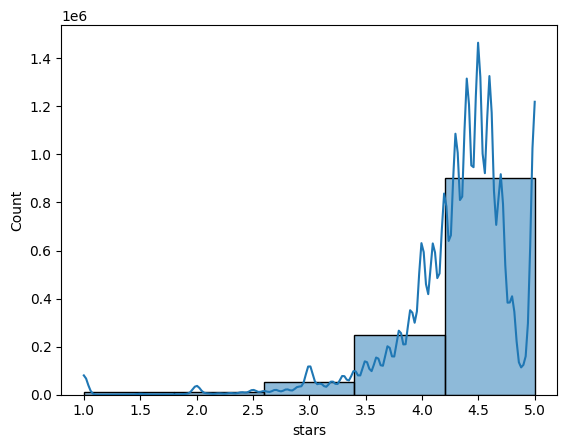

In [19]:
hist_rating = sns.histplot(data= df[df['stars'] > 0], x= df[df['stars'] > 0]['stars'] , bins=5, kde=True)

In [20]:
skew = df['stars'].skew()
kurt = df['stars'].kurt()
skew, kurt

(np.float64(0.08120735761080881), np.float64(-1.9260061280432994))

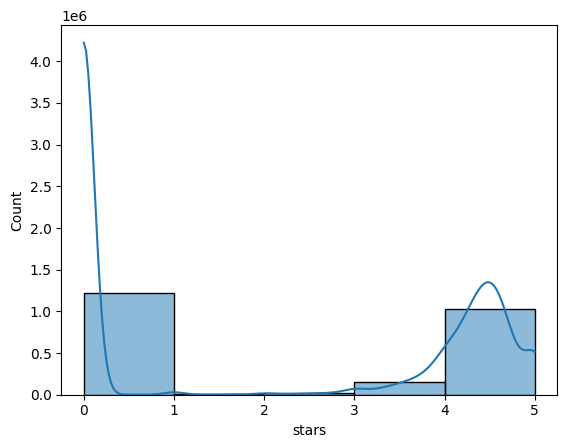

In [21]:
hist_rating = sns.histplot(data= df, x= df['stars'] , bins=5, kde=True)

si tenemos en cuenta los valores '0' de la variable stars, esta presenta un distribucion donde las calificaciones se concentran en los extremos entre 0-1 y 4-5 si no tenemos en cuenta el valor de '0' entonces encontramos una distribucion con un sesgo negativo con una cola hacia la izquierda y la mayotia de los valores concentrados a la derecha.